# Ex No 3 - Demonstrate Camera Calibration using python 


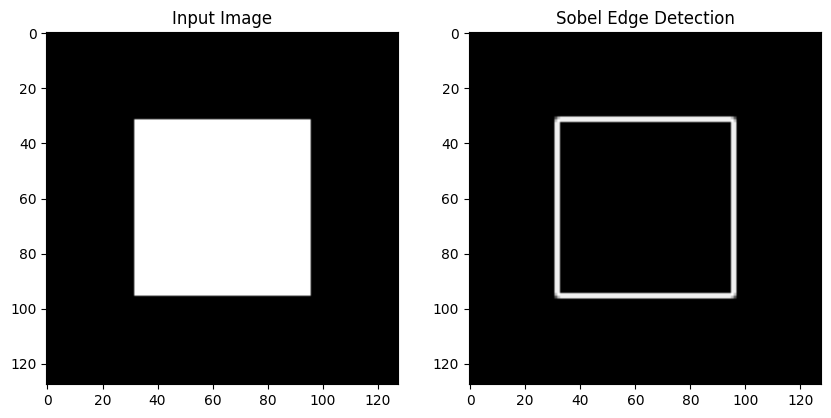

In [1]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

def sobel_edge_detection(image):
    # Sobel kernels
    sx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

    sy = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]])

    Ix = ndimage.convolve(image, sx, mode='constant')
    Iy = ndimage.convolve(image, sy, mode='constant')

    magnitude = np.hypot(Ix, Iy)
    return magnitude / magnitude.max()   # Normalize

# Create synthetic image (white square)
img = np.zeros((128, 128))
img[32:96, 32:96] = 1.0

edges = sobel_edge_detection(img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Sobel Edge Detection")

plt.show()


Detected lines (rho, theta):
(np.float64(0.0), np.float64(-0.7853981633974483))


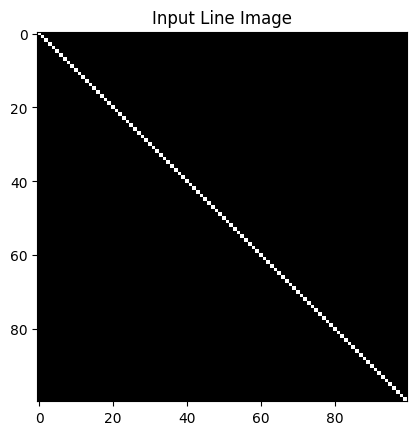

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def hough_line_detection(binary_edges, theta_step=0.5, threshold_ratio=0.6):
    h, w = binary_edges.shape
    diag = int(np.ceil(np.hypot(h, w)))

    rhos = np.linspace(-diag, diag, 2 * diag + 1)
    thetas = np.deg2rad(np.arange(-90, 90, theta_step))

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=int)

    y, x = np.nonzero(binary_edges > 0.1)

    for px, py in zip(x, y):
        for t_idx, theta in enumerate(thetas):
            rho = px * np.cos(theta) + py * np.sin(theta)
            rho_idx = np.argmin(np.abs(rhos - rho))
            accumulator[rho_idx, t_idx] += 1

    max_votes = accumulator.max()
    peaks = np.argwhere(accumulator >= threshold_ratio * max_votes)

    lines = []
    for rho_idx, theta_idx in peaks:
        lines.append((rhos[rho_idx], thetas[theta_idx]))

    return lines, accumulator

# Create synthetic diagonal line image
img = np.zeros((100, 100))
for i in range(100):
    img[i, i] = 1.0

lines, acc = hough_line_detection(img)

print("Detected lines (rho, theta):")
for line in lines:
    print(line)

plt.imshow(img, cmap='gray')
plt.title("Input Line Image")
plt.show()


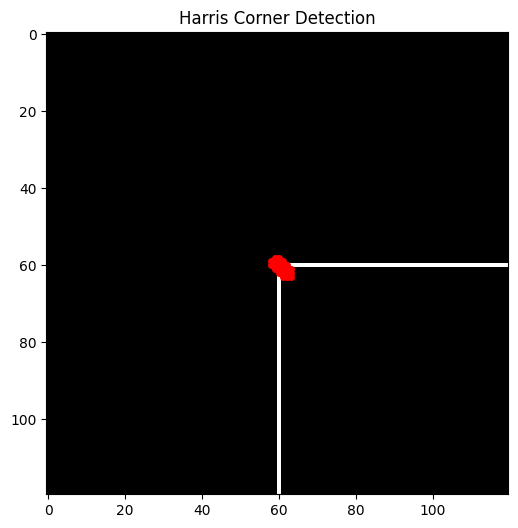

In [3]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

def harris_corners(gray, sigma=1.0, k=0.05, thresh=0.01):
    Ix = ndimage.sobel(gray, axis=1)
    Iy = ndimage.sobel(gray, axis=0)

    Ix2 = ndimage.gaussian_filter(Ix ** 2, sigma)
    Iy2 = ndimage.gaussian_filter(Iy ** 2, sigma)
    Ixy = ndimage.gaussian_filter(Ix * Iy, sigma)

    det = Ix2 * Iy2 - Ixy ** 2
    trace = Ix2 + Iy2
    R = det - k * (trace ** 2)

    corners = np.argwhere(R > thresh * R.max())
    return corners

# Create synthetic L-shape image
img = np.zeros((120, 120))
img[60, 60:] = 1.0
img[60:, 60] = 1.0

corners = harris_corners(img)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.plot(corners[:, 1], corners[:, 0], 'r.', markersize=8)
plt.title("Harris Corner Detection")
plt.show()


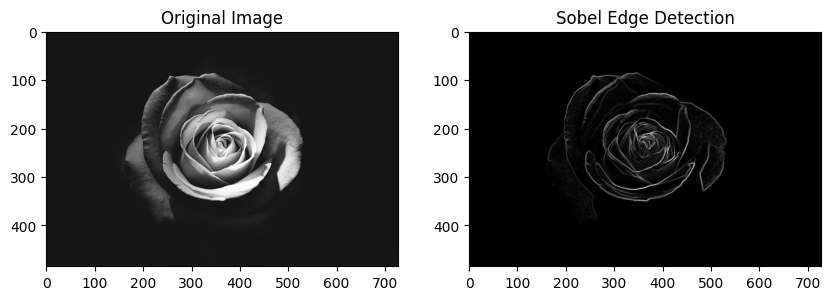

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
img = cv2.imread("C:\\Users\\91950\\Downloads\\sobel_flower.jpg", cv2.IMREAD_GRAYSCALE)

# Sobel gradients
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Gradient magnitude
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = (sobel_mag / sobel_mag.max()) * 255
sobel_mag = sobel_mag.astype(np.uint8)

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(sobel_mag, cmap='gray')
plt.title("Sobel Edge Detection")

plt.show()


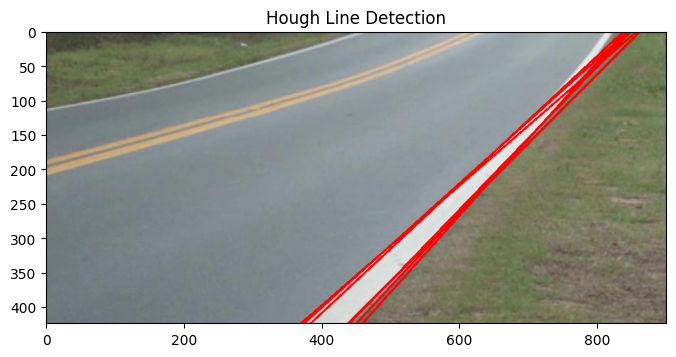

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("C:\\Users\\91950\\Downloads\\road.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Edge detection
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# Hough Line Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

# Draw detected lines
if lines is not None:
    for i in range(len(lines)):
        rho, theta = lines[i][0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Display
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Hough Line Detection")
plt.show()


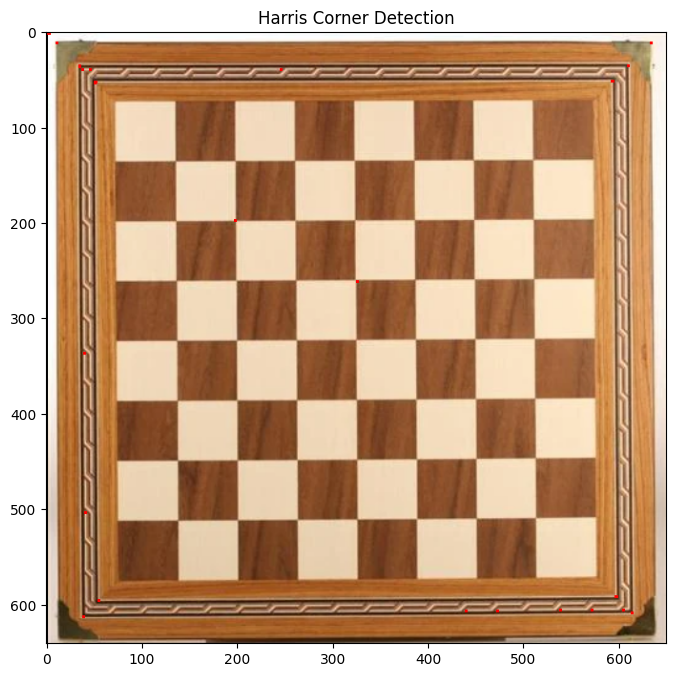

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("C:\\Users\\91950\\Downloads\\harris_chessboard.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = np.float32(gray)

# Harris Corner Detection
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

# Result dilation
dst = cv2.dilate(dst, None)

# Mark corners
img[dst > 0.01 * dst.max()] = [0, 0, 255]

# Display
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Harris Corner Detection")
plt.show()
